In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import( mean_absolute_error,mean_squared_error,r2_score)

In [6]:
df=pd.read_csv("data/train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [10]:
print("Dataset Shape :")
print(df.shape)
print("\n")

print("Column Names:")
print(df.columns)

Dataset Shape :
(1460, 81)


Column Names:
Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'Ga

In [11]:
df=df[['GrLivArea','BedroomAbvGr','FullBath','SalePrice']]
df.columns=['Area','Bedroom','Bathroom','Price']
df.head()

,Area,Bedroom,Bathroom,Price
0,1710,3,2,208500
1,1262,3,2,181500
2,1786,3,2,223500
3,1717,3,1,140000
4,2198,4,2,250000


In [12]:
print(df.isnull().sum())

Area        0
Bedroom     0
Bathroom    0
Price       0
dtype: int64


In [13]:
df.describe()

,Area,Bedroom,Bathroom,Price
count,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,180921.195890
std,525.480383,0.815778,0.550916,79442.502883
min,334.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,129975.000000
50%,1464.000000,3.000000,2.000000,163000.000000
75%,1776.750000,3.000000,2.000000,214000.000000
max,5642.000000,8.000000,3.000000,755000.000000


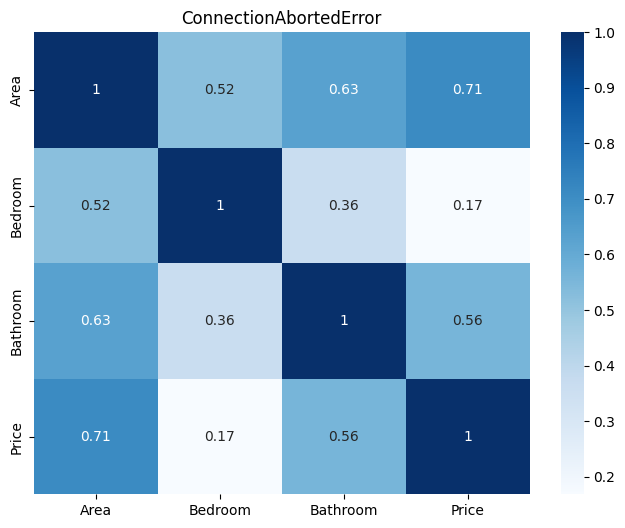

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='Blues')

plt.title("ConnectionAbortedError")
plt.show()

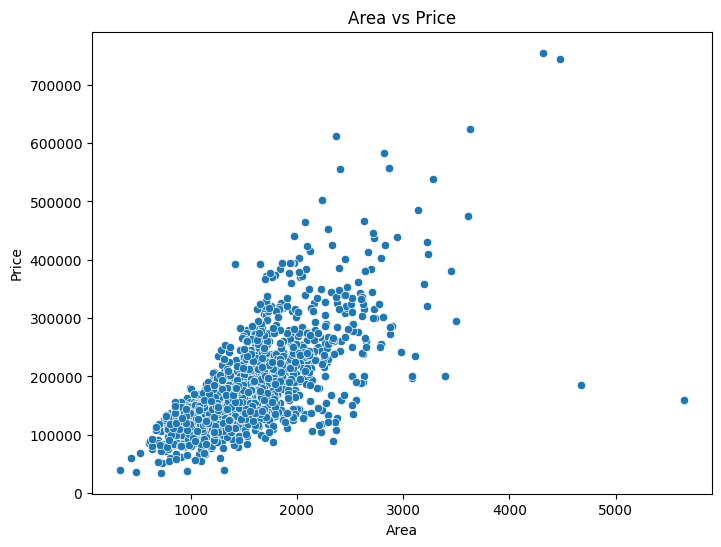

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['Area'],y=df['Price'])
plt.title("Area vs Price")
plt.xlabel("Area")
plt.ylabel("Price")
plt.show()

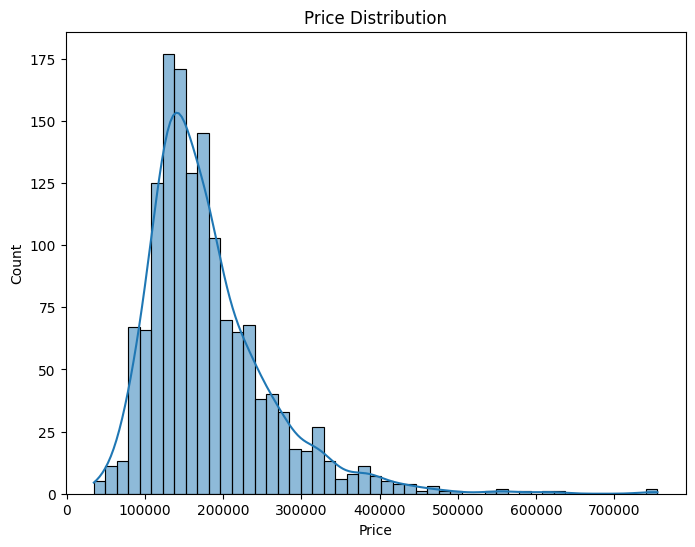

In [18]:
plt.figure(figsize=(8,6))
sns.histplot(df['Price'],kde=True)

plt.title("Price Distribution")
plt.show()

In [25]:
X = df[['Area', 'Bedroom', 'Bathroom']]
y=df['Price']

In [26]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

print("Training Data Shape:",X_train.shape)
print("Testing Data Shape:",X_test.shape)

Training Data Shape: (1168, 3)
Testing Data Shape: (292, 3)


In [27]:
model=LinearRegression()
model.fit(X_train,y_train)
print("Model Trained Successfully")


Model Trained Successfully


In [28]:
y_pred=model.predict(X_test)
print(y_pred[:5])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004]


In [29]:
results=pd.DataFrame({'Actual Price':y_test,'Predicted Price':y_pred})
results.head()

,Actual Price,Predicted Price
892,154500,113410.672553
1105,325000,305081.877759
413,115000,135904.785630
522,159000,205424.675641
1036,315500,227502.683490


In [30]:
#Model Evaluation 

#mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)

#mean_squared_error
mse=mean_squared_error(y_test,y_pred)

#root_mean_squared_error
rmse=np.sqrt(mse)

#r2_score
r2=r2_score(y_test,y_pred)

print("Model Evaluation :")
print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R-squared Score:", r2)

Model Evaluation :
Mean Absolute Error: 35788.0612924363
Mean Squared Error: 2806426667.247853
Root Mean Squared Error: 52975.71771338122
R-squared Score: 0.6341189942328371


In [34]:
# Predict custom house price
sample_house = pd.DataFrame(
    [[2000, 3, 2]],
    columns=['Area', 'Bedroom', 'Bathroom']
)


prediction = model.predict(sample_house)

print("Predicted House Price:")

print(prediction[0])


Predicted House Price:
240377.51479736285


In [32]:
# Model coefficients

coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

print("\nIntercept:", model.intercept_)

    Feature   Coefficient
0      Area    104.026307
1   Bedroom -26655.165357
2  Bathroom  30014.324109

Intercept: 52261.748626944594


In [35]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))